In [5]:
# https://machinelearningmastery.com/building-a-single-layer-neural-network-in-pytorch/

In [1]:
import torch
import matplotlib.pyplot as plt

In [2]:
# generate synthetic the data
X = torch.arange(-30, 30, 1).view(-1, 1).type(torch.FloatTensor)
Y = torch.zeros(X.shape[0])
Y[(X[:, 0] <= -10)] = 1.0
Y[(X[:, 0] > -10) & (X[:, 0] < 10)] = 0.5
Y[(X[:, 0] > 10)] = 0

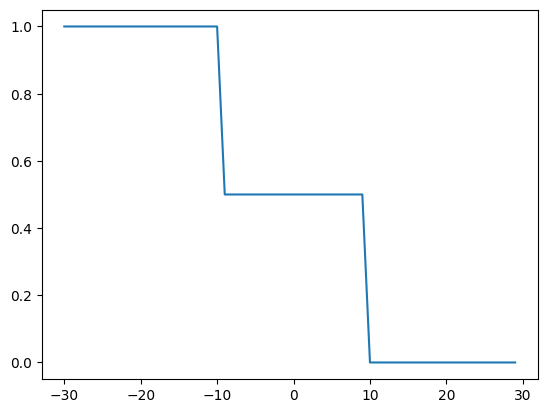

In [3]:
plt.plot(X, Y)
plt.show()

In [4]:
# Define the class for single layer NN

class one_layer_net(torch.nn.Module):
    # Constructor
    def __init__(self, input_size, hidden_neurons, output_size):
        super(one_layer_net, self).__init__() # Chama o construtor da classe mãe (torch.nn.Module)
        
        # hidden layer
        self.linear_one = torch.nn.Linear(input_size, hidden_neurons) # Primeira camada linear: entrada → camada oculta
        self.linear_two = torch.nn.Linear(hidden_neurons, output_size) # Segunda camada linear: camada oculta → saída

        # defining layers as attributes
        self.layer_in = None # Armazena saída da primeira camada (pré-ativação)
        self.act = None # Armazena saída após ativação (sigmoid)
        self.layer_out = None # Armazena saída da segunda camada (pré-ativação final)

    # Prediction function
    def forward(self, x): # Define como os dados passam pela rede (propagação direta)

        self.layer_in = self.linear_one(x) # Calcula saída da primeira camada
        self.act = torch.sigmoid(self.layer_in) # Aplica função de ativação sigmoid à saída da primeira camada
        
        self.layer_out = self.linear_two(self.act) # Calcula saída da segunda camada
        y_pred = torch.sigmoid(self.linear_two(self.act))  # Aplica sigmoid na saída final (valor previsto)
        
        return y_pred

Entrada x
   │
   ▼
[Camada Linear 1]  --> self.linear_one(x)   (input_size → hidden_neurons)
   │
   ▼
[Ativação Sigmoid] --> self.act
   │
   ▼
[Camada Linear 2]  --> self.linear_two(self.act)   (hidden_neurons → output_size)
   │
   ▼
[Ativação Sigmoid] --> y_pred
   │
   ▼
Saída final

Aqui está o fluxo do código em forma sequencial e compacta:

1. **Entrada** `x` entra na **primeira camada linear** (`self.linear_one`) → calcula $x \cdot W_1^T + b_1$ → salva em `self.layer_in`.
2. `self.layer_in` passa pela **função sigmoid** → salva em `self.act` (saída ativada da primeira camada).
3. `self.act` entra na **segunda camada linear** (`self.linear_two`) → calcula $\text{act} \cdot W_2^T + b_2$ → salva em `self.layer_out`.
4. `self.layer_out` passa por outra **função sigmoid** → resultado final é `y_pred`.
5. **Saída** `y_pred` é retornada como previsão da rede.



In [5]:
# create the model
model = one_layer_net(1, 2, 1)

In [6]:
model.eval()

one_layer_net(
  (linear_one): Linear(in_features=1, out_features=2, bias=True)
  (linear_two): Linear(in_features=2, out_features=1, bias=True)
)

In [7]:
def criterion(y_pred, y):
    out = -1 * torch.mean(y * torch.log(y_pred) + (1 - y) * torch.log(1 - y_pred))
    return out 

optimizer = torch.optim.SGD(model.parameters(), lr = 0.01)

In [9]:
import pdb

In [ ]:
# define the training loop

epochs = 5000
cost = []
total = 0



for epoch in range(epochs):
    total = 0 
    epoch = epoch + 1
    for x, y in zip(X, Y):
        yhat = model(x)
        
        loss = criterion(yhat, y)
        print(y)
        print(yhat)
        print(epoch)
        pdb.set_trace()
        
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()
        # get total loss
        total += loss.item()
    cost.append(total)
    if epoch % 100 == 0:
        print(str(epoch) + " " + "epochs done!") # veja resultados a cada 1000 epocas
        # plot the result of function approximator
        plt.plot(X.numpy(), model(X).detach().numpy())
        plt.plot(X.numpy(), Y.numpy(), "m")
        plt.xlabel("x")
        plt.show()

tensor(1.)
tensor([0.9955], grad_fn=<SigmoidBackward0>)
1
> /tmp/ipykernel_990/1647034600.py(21)<module>()
     19         pdb.set_trace()
     20 
---> 21         loss.backward()
     22         optimizer.step()
     23         optimizer.zero_grad()



ipdb>  c


tensor(1.)
tensor([0.9955], grad_fn=<SigmoidBackward0>)
1
> /tmp/ipykernel_990/1647034600.py(21)<module>()
     19         pdb.set_trace()
     20 
---> 21         loss.backward()
     22         optimizer.step()
     23         optimizer.zero_grad()



ipdb>  c


tensor(1.)
tensor([0.9955], grad_fn=<SigmoidBackward0>)
1
> /tmp/ipykernel_990/1647034600.py(21)<module>()
     19         pdb.set_trace()
     20 
---> 21         loss.backward()
     22         optimizer.step()
     23         optimizer.zero_grad()



...

tensor(1.)
tensor([0.9954], grad_fn=<SigmoidBackward0>)
1
> /tmp/ipykernel_990/1647034600.py(21)<module>()
     19         pdb.set_trace()
     20 
---> 21         loss.backward()
     22         optimizer.step()
     23         optimizer.zero_grad()



ipdb>  c


tensor(1.)
tensor([0.9954], grad_fn=<SigmoidBackward0>)
1
> /tmp/ipykernel_990/1647034600.py(21)<module>()
     19         pdb.set_trace()
     20 
---> 21         loss.backward()
     22         optimizer.step()
     23         optimizer.zero_grad()



ipdb>  c


tensor(1.)
tensor([0.9953], grad_fn=<SigmoidBackward0>)
1
> /tmp/ipykernel_990/1647034600.py(21)<module>()
     19         pdb.set_trace()
     20 
---> 21         loss.backward()
     22         optimizer.step()
     23         optimizer.zero_grad()



In [12]:
y.item()

1.0

In [15]:
zip(X, Y)

# Pra seguir

```
import torch
import torch.nn as nn
import torch.optim as optim

# Suponha: X_latents ∈ R^{N x D} (vetores latentes), y_labels ∈ {0,1,2,3,4}
# Exemplo fake só pra rodar:
N, D, C = 200, 16, 5
X_latents = torch.randn(N, D)
y_labels = torch.randint(0, C, (N,))

# Modelo: mesma estrutura, mas output_size=5 e sem sigmoid no final
class OneLayerNetMC(nn.Module):
    def __init__(self, input_size, hidden_neurons, output_size=5):
        super().__init__()
        self.linear_one = nn.Linear(input_size, hidden_neurons)
        self.linear_two = nn.Linear(hidden_neurons, output_size)

    def forward(self, x):
        x = torch.sigmoid(self.linear_one(x))   # ativação na oculta (pode trocar por ReLU)
        logits = self.linear_two(x)             # NÃO aplica sigmoid/softmax aqui
        return logits                            # CrossEntropyLoss espera logits

model = OneLayerNetMC(input_size=D, hidden_neurons=32, output_size=C)

# Perda e optimizador
criterion = nn.CrossEntropyLoss()               # multi-classe
optimizer = optim.SGD(model.parameters(), lr=0.01)

# Treino (simples, sem DataLoader)
epochs = 1000
for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()
    logits = model(X_latents)                   # [N, C]
    loss = criterion(logits, y_labels)          # y_labels: LongTensor com rótulos 0..C-1
    loss.backward()
    optimizer.step()
    if (epoch + 1) % 200 == 0:
        with torch.no_grad():
            preds = logits.argmax(dim=1)
            acc = (preds == y_labels).float().mean().item()
        print(f"epoch {epoch+1}: loss={loss.item():.4f} acc={acc:.3f}")

# Inferência em novos latentes:
with torch.no_grad():
    new_logits = model(torch.randn(4, D))
    probs = torch.softmax(new_logits, dim=1)    # probabilidades por classe
    preds = probs.argmax(dim=1)                 # classe prevista (0..4)
    print("preds:", preds.tolist())

```

Se você quer transformar sua rede em um classificador multi-classe e começar a treinar com suas representações latentes, a metodologia de trabalho costuma seguir uma ordem bem pragmática:

---

### **1. Preparar os dados**

* **Entradas** → suas representações latentes (por exemplo, vetores de tamanho *n*).
* **Saídas (labels)** → inteiros de `0` a `4` para as 5 classes.
* Separar em **treino**, **validação** e **teste** (ex.: 70/15/15).

---

### **2. Começar pequeno**

* Não joga tudo na rede de cara.
* Treina **com um subconjunto pequeno** (ex.: 100–500 amostras) para confirmar:

  * O código roda sem erro.
  * A perda diminui.
  * A acurácia sobe.
* Isso economiza tempo e ajuda a detectar bugs antes de usar todo o dataset.

---

### **3. Escolher arquitetura inicial**

* Mantém sua rede simples (mesma estrutura que já tem) e só muda:

  * **output\_size = 5**
  * **última ativação** → softmax (ou nada se usar `CrossEntropyLoss`).
* Função de perda:

  ```python
  criterion = torch.nn.CrossEntropyLoss()
  ```
* Otimizador: SGD ou Adam com `lr` pequeno (ex.: 0.001–0.01).

---

### **4. Ajustar parâmetros (tuning)**

* Testa diferentes:

  * Número de neurônios na camada oculta.
  * Taxa de aprendizado (`lr`).
  * Tamanho do batch.
  * Número de épocas.
* Usa **validação** para decidir quais valores são melhores (não olha para o teste ainda).

---

### **5. Monitorar**

* Sempre guarda:

  * Perda no treino.
  * Perda e acurácia na validação.
* Para comparar runs, salva modelos e métricas.

---

### **6. Teste final**

* Depois de escolher hiperparâmetros, treina com **treino+validação** e mede desempenho no conjunto de teste.

---

Se você quiser, posso já te montar **uma versão adaptada da sua rede e loop de treino** para classificação multi-classe usando latentes como entrada. Assim você já teria algo pronto para rodar primeiro em um subconjunto pequeno.
